In [1]:
#DATA PARSING AND BASELINE MODELING
#setup environment & process dataset
import pandas as pd
import numpy as np
import json 
import os 



In [ ]:
#load the AI students imact dataset
df = pd.read_csv(r"

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [3]:
# basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [4]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')


In [5]:
for col in df.columns:
    print(col)

Student_ID
Major_Category
Year_of_Study
Pre_Semester_GPA
Weekly_GenAI_Hours
Primary_Use_Case
Prompt_Engineering_Skill
Tool_Diversity
Paid_Subscription
Traditional_Study_Hours
Perceived_AI_Dependency
Institutional_Policy
Anxiety_Level_During_Exams
Post_Semester_GPA
Skill_Retention_Score
Burnout_Risk_Level


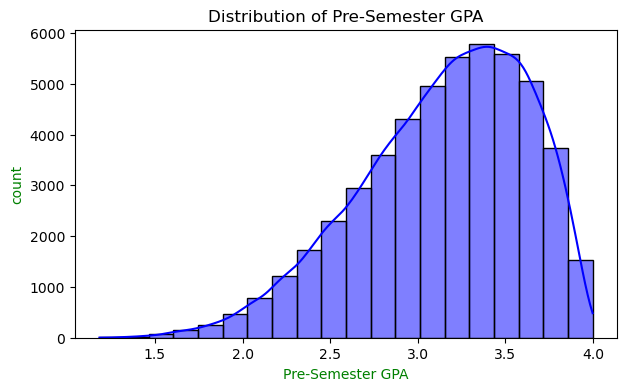

In [6]:
# GPA Distribution 
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,4))
sns.histplot(df['Pre_Semester_GPA'], bins=20, kde=True, color='blue')
plt.title('Distribution of Pre-Semester GPA')
plt.xlabel('Pre-Semester GPA', color='green')
plt.ylabel('count', color='green')
plt.show()


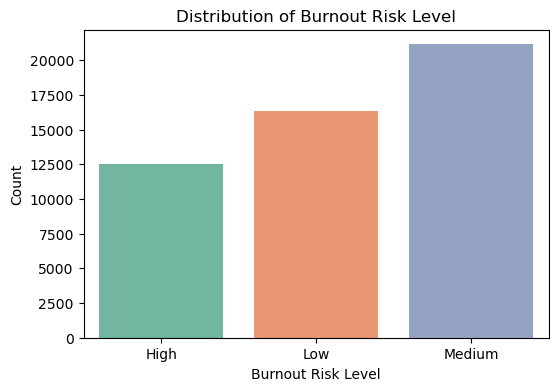

In [7]:
# Distribution of Burnout_Risk_Level 
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='Burnout_Risk_Level',hue='Burnout_Risk_Level', data=df,palette='Set2',legend=False)
plt.title('Distribution of Burnout Risk Level')
plt.xlabel('Burnout Risk Level')
plt.ylabel('Count')
plt.show()

In [8]:
#OCR PIPELINE TESSERACT AND PDFIMAGE
# installing the required libraries for OCR and PDF processing
import pytesseract
from pdf2image import convert_from_path
from PIL import Image
import os

In [9]:
#extracting text from a img using tesseract OCR
import pytesseract
from PIL import Image
img=Image.open('D:\zaalima\project 1\page_1.png')
text=pytesseract.image_to_string(img)
print(text)

Al Student Impact Dataset - Sample Report

Dataset Size: 50000 rows x 16 columns

Columns:

Student_ID
Major_Category
Year_of_Study
Pre_Semester_GPA
Weekly_GenAl_Hours
Primary_Use_Case
Prompt_Engineering_Skill
Tool_Diversity
Paid_Subscription
Traditional_Study_Hours
Perceived_Al_Dependency
Institutional_Policy
Anxiety_Level_During_Exams
Post_Semester_GPA

Skill_ Retention Score

Burnout_Risk_Level

First 5 Records (Sample)

Student_ID Major_Category Year_of_Study Pre_Semester_GPA Weekly _GenAI_Hours
Primary_Use_Case Prompt_Engineering_Skill Tool_Diversity Paid_Subscription
Traditional_Study_Hours Perceived_AI_Dependency Institutional_Policy
Anxiety_Level_During_Exams Post_Semester_GPA Skill_Retention_Score
Burnout_Risk_Level 0 100001 Humanities Senior 2.418 23.31 Copywriting/Drafting
Beginner 1 True 8.13 5 Allowed_With_Citation 6 2.393 86.44 High 1 100002 Medical
Junior 3.821 1.12 Ideation Advanced 5 False 16.65 3 Allowed_With_Citation 9 3.696
69.39 Low 2 100003 Business Freshman 3.398

In [10]:
#save extracted text to a file
with open('extracted_text.txt', 'w') as f:
    f.write(text)
    print("Text extracted and saved to extracted_text.txt")


Text extracted and saved to extracted_text.txt


In [11]:
#TRAIN BASELINE NER MODEL USING SPACY
# installing spacy and downloading the English language model
!pip install spacy -q

!python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [12]:
# create blank spacy model and add NER component
#add custom labels to the NER component
import spacy
from spacy.training import Example
npl = spacy.load('en_core_web_sm')
ner = npl.get_pipe('ner')
ner.add_label('GPA')
ner.add_label('Burnout_Risk_Level')
ner.add_label('Study_Hours_Per_Week')
ner.add_label('Sleep_Hours_Per_Night')
print("pipeline components:", npl.pipe_names)

pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [13]:
# training data 
TRAIN_DATA = [
    ("The student's Pre-Semester GPA is 3.5", {'entities': [(24, 27, 'GPA')]}),
    ("The student has a Burnout Risk Level of High", {'entities': [(28, 32, 'Burnout_Risk_Level')]}),
    ("The student studies for 15 hours per week", {'entities': [(17, 19, 'Study_Hours_Per_Week')]}),
    ("The student sleeps for 6 hours per night", {'entities': [(17, 18, 'Sleep_Hours_Per_Night')]})
]
print("Training data:", TRAIN_DATA)

Training data: [("The student's Pre-Semester GPA is 3.5", {'entities': [(24, 27, 'GPA')]}), ('The student has a Burnout Risk Level of High', {'entities': [(28, 32, 'Burnout_Risk_Level')]}), ('The student studies for 15 hours per week', {'entities': [(17, 19, 'Study_Hours_Per_Week')]}), ('The student sleeps for 6 hours per night', {'entities': [(17, 18, 'Sleep_Hours_Per_Night')]})]


In [14]:
#training the NER model
optimizer = npl.resume_training()
for epoch in range(3):
    for text, annotations in TRAIN_DATA:
        example = Example.from_dict(npl.make_doc(text), annotations)

        npl.update([example], sgd=optimizer)
        drop = 0.5
        losses = {}
        npl.update([example], sgd=optimizer, drop=drop, losses=losses)
        print(f"Epoch {epoch+1} Losses: {losses}")
    

c:\Users\Dell\anaconda3\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "The student's Pre-Semester GPA is 3.5" with entities "[(24, 27, 'GPA')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(


Epoch 1 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(0.23237677)}
Epoch 1 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(0.29097342)}


c:\Users\Dell\anaconda3\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "The student has a Burnout Risk Level of High" with entities "[(28, 32, 'Burnout_Risk_Level')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\Dell\anaconda3\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "The student studies for 15 hours per week" with entities "[(17, 19, 'Study_Hours_Per_Week')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(


Epoch 1 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(1.593669)}
Epoch 1 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(1.5701454)}


c:\Users\Dell\anaconda3\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "The student sleeps for 6 hours per night" with entities "[(17, 18, 'Sleep_Hours_Per_Night')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(


Epoch 2 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(0.00079062145)}
Epoch 2 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(5.2430158e-05)}
Epoch 2 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(0.0013667878)}
Epoch 2 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(0.0024625587)}
Epoch 3 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(0.0007083121)}
Epoch 3 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(8.107107e-06)}
Epoch 3 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(0.00018918593)}
Epoch 3 Losses: {'tok2vec': 0.0, 'tagger': 0.0, 'parser': 0.0, 'ner': np.float32(8.604109e-07)}


In [15]:
# testing the trained model on new text
test_text = "The student's Pre-Semester GPA is 3.5 and the Burnout Risk Level is High."
TRAIN_DATA = [
(
"The student's Pre-Semester GPA is 3.5 and the Burnout Risk Level is High.",
{
"entities":[
(14, 30, "GPA"),
(43, 61, "BURNOUT")
]
}
)
]
print("Test data:", TRAIN_DATA)

Test data: [("The student's Pre-Semester GPA is 3.5 and the Burnout Risk Level is High.", {'entities': [(14, 30, 'GPA'), (43, 61, 'BURNOUT')]})]


In [16]:
# test the trained NER model on the test text
import spacy
nlp = spacy.load("en_core_web_sm")


In [17]:
test_text = "The student's Pre-Semester GPA is 3.5 and the Burnout Risk Level is High"

doc = nlp(test_text)

for ent in doc.ents:
    print(ent.text, ent.label_)

Pre-Semester GPA ORG
3.5 CARDINAL
the Burnout Risk Level ORG


In [18]:
# Test the trained NER model

test_texts = [
    "The student's Pre-Semester GPA is 3.5 and the Burnout Risk Level is High"
]

for doc_text in test_texts:
    doc = nlp(doc_text)
    print(f"\nText: {doc_text}")
    for ent in doc.ents:
        print(f"Entity: {ent.text} | Label: {ent.label_} | Start: {ent.start_char} | End: {ent.end_char}")


Text: The student's Pre-Semester GPA is 3.5 and the Burnout Risk Level is High
Entity: Pre-Semester GPA | Label: ORG | Start: 14 | End: 30
Entity: 3.5 | Label: CARDINAL | Start: 34 | End: 37
Entity: the Burnout Risk Level | Label: ORG | Start: 42 | End: 64


In [19]:
doc = nlp("The student's Pre-Semester GPA is 3.5 and the Burnout Risk Level is High")

for ent in doc.ents:
    print(f"Entity: {ent.text} | Label: {ent.label_}")

Entity: Pre-Semester GPA | Label: ORG
Entity: 3.5 | Label: CARDINAL
Entity: the Burnout Risk Level | Label: ORG


In [20]:
#save the trained NER model 
nlp.to_disk('baseline_ner_model')
print('NER model saved successfully')

NER model saved successfully


In [21]:
# SAVE DATAFRAME AS CSV
df.to_csv("output.csv",index=True)

In [22]:
# SAVE DATAFRAME AS EXCEL
df.to_excel("output.xlsx",index=True)

In [23]:
# SAVE FILTERED DATA
filtered_df = df[df['Major_Category'] == 'STEM']
filtered_df.to_csv("stem_students.csv", index=False)

In [24]:
# SAVE TEXT OUTPUT
with open("result.txt", "w") as f:
    f.write(df.head().to_string())